In [1]:
# import Providentia
import providentia as prv

In [2]:
# magic to make plots appear inline
%matplotlib inline

# Initialise object

In [3]:
provi = prv.Providentia('trainings/20260505_EGU/egu.conf')

# Run download mode

In [4]:
provi.download()

Starting Providentia download...

Starting LOCAL section download...



Which type of data do you want to download? Observational, modelled or both? ([both]/obs/mod):  obs



Using 12 CPUs.



Do you want to download observational data from the BSC remote machine? (Otherwise, GHOST observational data will be retrieved from Zenodo) ([y]/n):  y



----------------------------------------


GHOST observations to download (1):

  - /home/avilanov/data/providentia/obs/ghost/GHOST/1.5/hourly/sconco3, source: /gpfs/projects/bsc32/AC_cache/obs/ghost/GHOST/1.5/hourly/sconco3 (storage5)


# Run interpolation

In [5]:
provi.interpolate()

Starting Providentia interpolation...

Starting LOCAL section interpolation...

Variables used for the interpolation:

ghost_version: 1.5
start_date: 201801
end_date: 201802
models:
 - cams_reanalysis_ensemble_validated-regional-000 (CAMS Regional)
 - cams_reanalysis-global-000 (CAMS Global)
species: ['sconco3']
network: ['GHOST']
resolution: ['hourly']
model_resolution: ['hourly', '3hourly']
forecast: []
interp_spinup_timesteps: 0
interp_model_downsampling: mean
interp_model_upsampling: fill
interp_n_neighbours: 4
interp_reverse_vertical_orientation: False
interp_chunk_size: 16
interp_job_array_limit: 100
mod_root: /home/avilanov/data/providentia/mod
ghost_root: /home/avilanov/data/providentia/obs/ghost
nonghost_root: /home/avilanov/data/providentia/obs/nonghost
mod_to_interp_root: /home/avilanov/data/providentia/mod_to_interp
interp_multiprocessing: True

MODEL: CAMS Regional

1 observation file(s) for GHOST and hourly resolution were found in /home/avilanov/data/providentia/obs/ghos

# Load data

In [6]:
provi.load()


Updating file tree /home/avilanov/software/providentia/settings/internal/ghost_filetree_1.5.json...
Updating file tree /home/avilanov/software/providentia/settings/internal/nonghost_filetree.json...
Reading data

OBSERVATIONS
 - GHOST|sconco3
MODELS
 - cams_reanalysis_ensemble_validated-regional-000 (CAMS Regional)
 - cams_reanalysis-global-000 (CAMS Global)
Resetting data filters to when class was initialised, loading LOCAL·All subsection filters.
Filtering data


# Save data to netCDF

In [7]:
provi.save(format='nc')

Data saved to /home/avilanov/software/providentia/saved_data/PRV_20260709_1116.nc


# Get data in memory

In [8]:
# return data in memory (in Xarray format)
data = provi.data(format='xr')
data

<xarray.Dataset> Size: 49MB
Dimensions:                                                                         (
                                                                                     data_label: 3,
                                                                                     ghost_data_variable: 3,
                                                                                     station_GHOST|sconco3: 2289,
                                                                                     time: 744,
                                                                                     qa: 79,
                                                                                     flag: 188,
                                                                                     month: 1)
Coordinates:
  * time                                                                            (time) datetime64[ns] 6kB ...
Dimensions without coordinates: data_label, ghost_data_variable,
                                station_GHOST|sconco3, qa, flag, month
Data variables: (12/64)
    data_labels                                                                     (data_label) <U13 156B ...
    ghost_data_variables                                                            (ghost_data_variable) <U20 240B ...
    GHOST|sconco3_data                                                              (data_label, station_GHOST|sconco3, time) float32 20MB ...
    GHOST|sconco3_ghost_data                                                        (ghost_data_variable, station_GHOST|sconco3, time) float32 20MB ...
    GHOST|sconco3_qa                                                                (qa) float32 316B ...
    GHOST|sconco3_flags                                                             (flag) float32 752B ...
    ...                                                                              ...
    GHOST|sconco3_primary_sampling_instrument_name                                  (station_GHOST|sconco3, month) <U3 27kB ...
    GHOST|sconco3_sample_preparation_types                                          (station_GHOST|sconco3, month) <U3 27kB ...
    GHOST|sconco3_sample_preparation_techniques                                     (station_GHOST|sconco3, month) <U3 27kB ...
    GHOST|sconco3_measurement_methodology                                           (station_GHOST|sconco3, month) <U44 403kB ...
    GHOST|sconco3_measuring_instrument_name                                         (station_GHOST|sconco3, month) <U22 201kB ...
    GHOST|sconco3_measuring_instrument_sampling_type                                (station_GHOST|sconco3, month) <U21 192kB ...
Attributes:
    title:         Saved data from Providentia
    institution:   Barcelona Supercomputing Center
    source:        Providentia
    data_version:  1.5

# Calculate statistics

In [9]:
# calculate and return statistics
stat = provi.statistic('r', labela='OBS', labelb='CAMS Regional', per_station=True)
stat

array([[0.81313716, 0.89715188, 0.75457755, ..., 0.96190635, 0.89958895,
        0.91454821]], shape=(1, 2289))

# Filter by country

In [10]:
# filter data by country metadata 
provi.reset()
provi.filter('country', keep=['Austria'])
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 2MB
Dimensions:                                                                         (
                                                                                     data_label: 3,
                                                                                     ghost_data_variable: 3,
                                                                                     station_GHOST|sconco3: 116,
                                                                                     time: 744,
                                                                                     qa: 79,
                                                                                     flag: 188,
                                                                                     month: 1)
Coordinates:
  * time                                                                            (time) datetime64[ns] 6kB ...
Dimensions without coordinates: data_label, ghost_data_variable,
                                station_GHOST|sconco3, qa, flag, month
Data variables: (12/64)
    data_labels                                                                     (data_label) <U13 156B ...
    ghost_data_variables                                                            (ghost_data_variable) <U20 240B ...
    GHOST|sconco3_data                                                              (data_label, station_GHOST|sconco3, time) float32 1MB ...
    GHOST|sconco3_ghost_data                                                        (ghost_data_variable, station_GHOST|sconco3, time) float32 1MB ...
    GHOST|sconco3_qa                                                                (qa) float32 316B ...
    GHOST|sconco3_flags                                                             (flag) float32 752B ...
    ...                                                                              ...
    GHOST|sconco3_primary_sampling_instrument_name                                  (station_GHOST|sconco3, month) <U3 1kB ...
    GHOST|sconco3_sample_preparation_types                                          (station_GHOST|sconco3, month) <U3 1kB ...
    GHOST|sconco3_sample_preparation_techniques                                     (station_GHOST|sconco3, month) <U3 1kB ...
    GHOST|sconco3_measurement_methodology                                           (station_GHOST|sconco3, month) <U22 10kB ...
    GHOST|sconco3_measuring_instrument_name                                         (station_GHOST|sconco3, month) <U14 6kB ...
    GHOST|sconco3_measuring_instrument_sampling_type                                (station_GHOST|sconco3, month) <U21 10kB ...
Attributes:
    title:         Saved data from Providentia
    institution:   Barcelona Supercomputing Center
    source:        Providentia
    data_version:  1.5

# Make plots

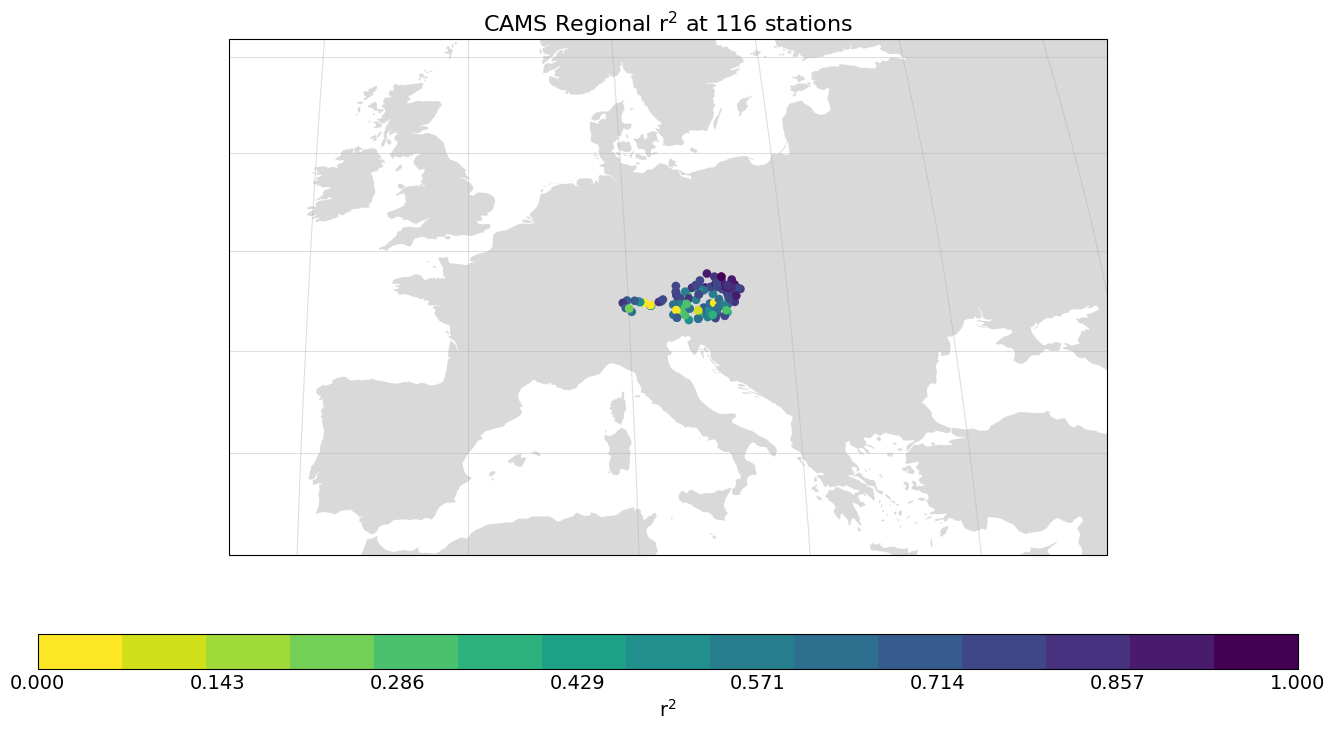

In [11]:
# make a map plot (r2 statistic)
provi.plot('map-r2', labela='OBS', labelb='CAMS Regional', map_extent=[-15, 40, 35, 61])

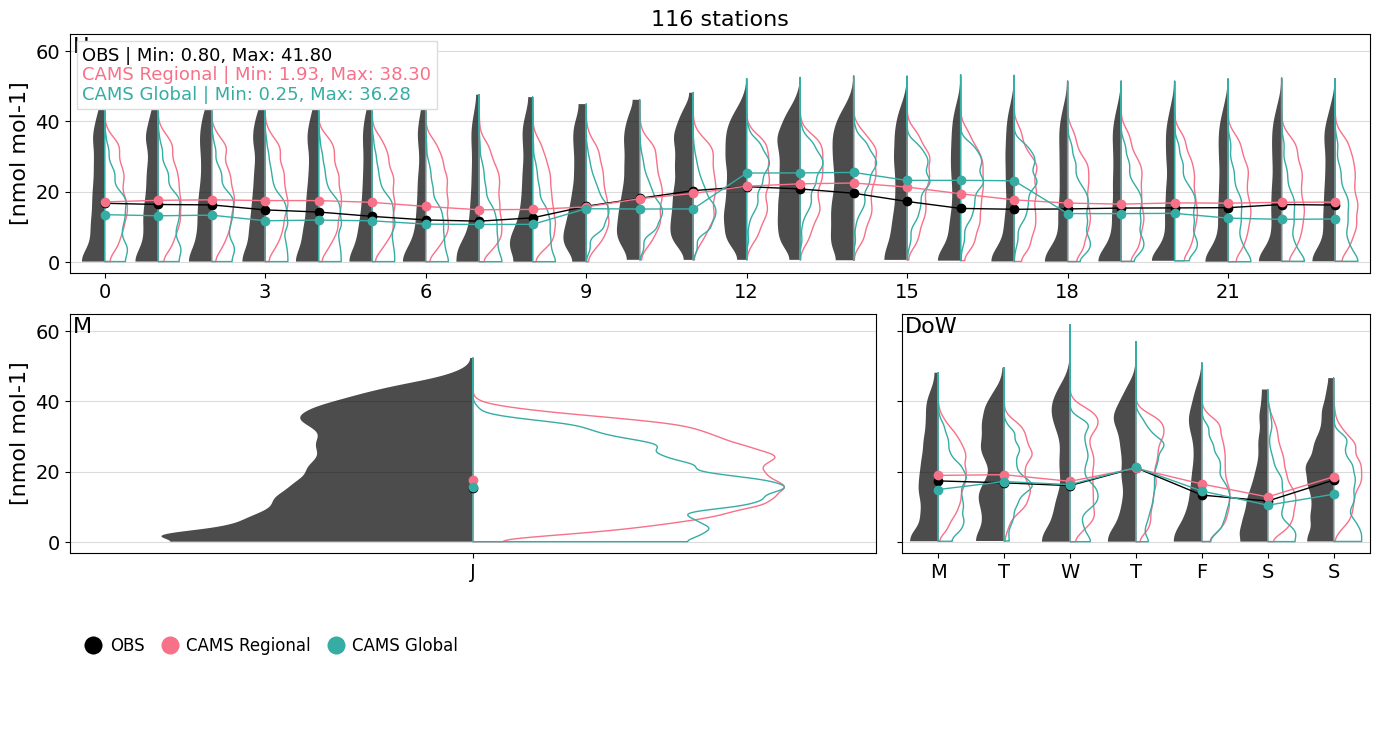

In [12]:
# make a periodic-violin plot
provi.plot('periodic-violin', plot_options=['annotate'])

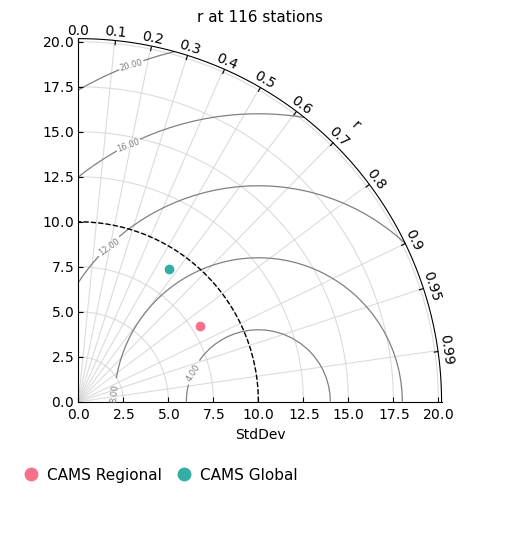

In [13]:
# make a Taylor diagram
provi.plot('taylor-r')

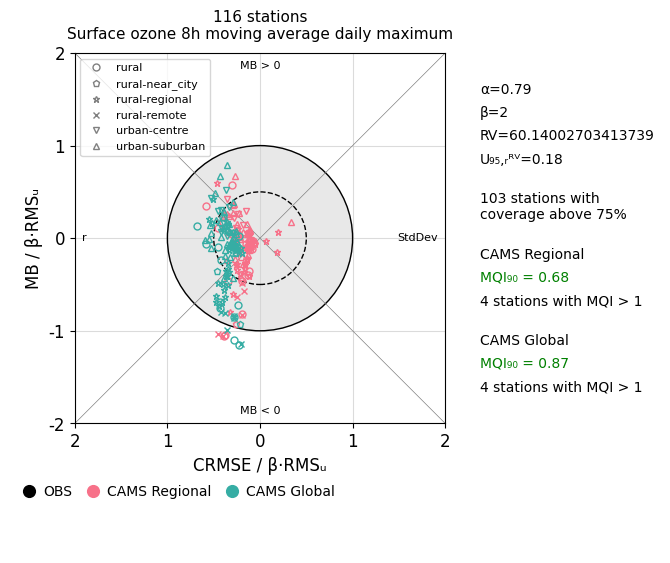

In [14]:
# make a fairmode-target plot
provi.plot('fairmode-target', annotate=True)

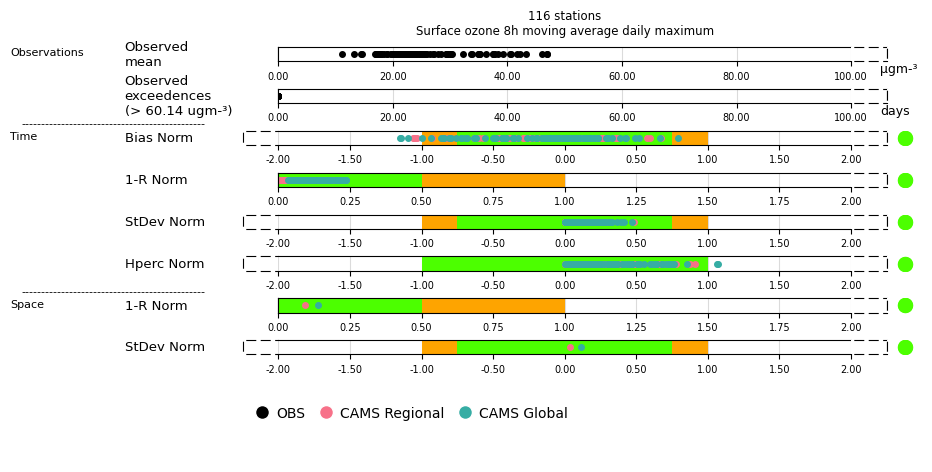

In [15]:
# make a fairmode-statsummary plot
provi.plot('fairmode-statsummary')

Resetting data filters to when class was initialised, loading LOCAL·All subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Austria subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·France subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Germany subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·UK subsection filters.
Filtering data
Resetting all data filters.
Filtering data


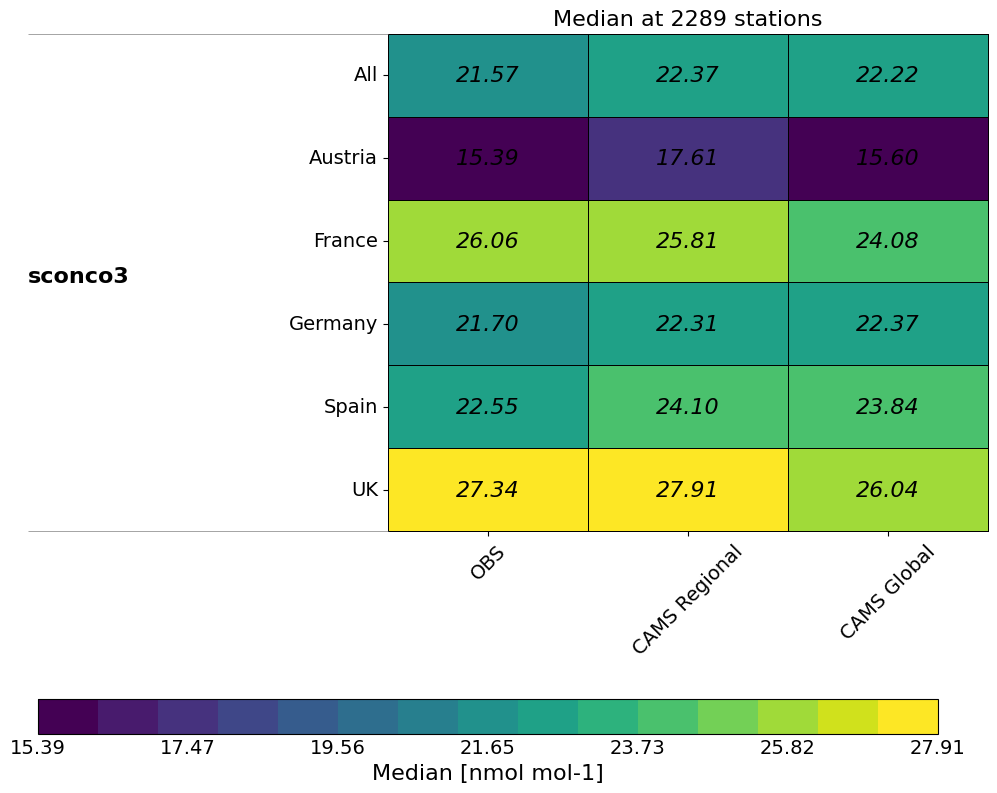

In [16]:
# make a heatmap (Median stat)
#provi.reset(initialise=True)
provi.plot('heatmap-Median', annotate=True, multispecies=True)

Resetting data filters to when class was initialised, loading LOCAL·All subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Austria subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·France subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Germany subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·UK subsection filters.
Filtering data
Resetting all data filters.
Filtering data


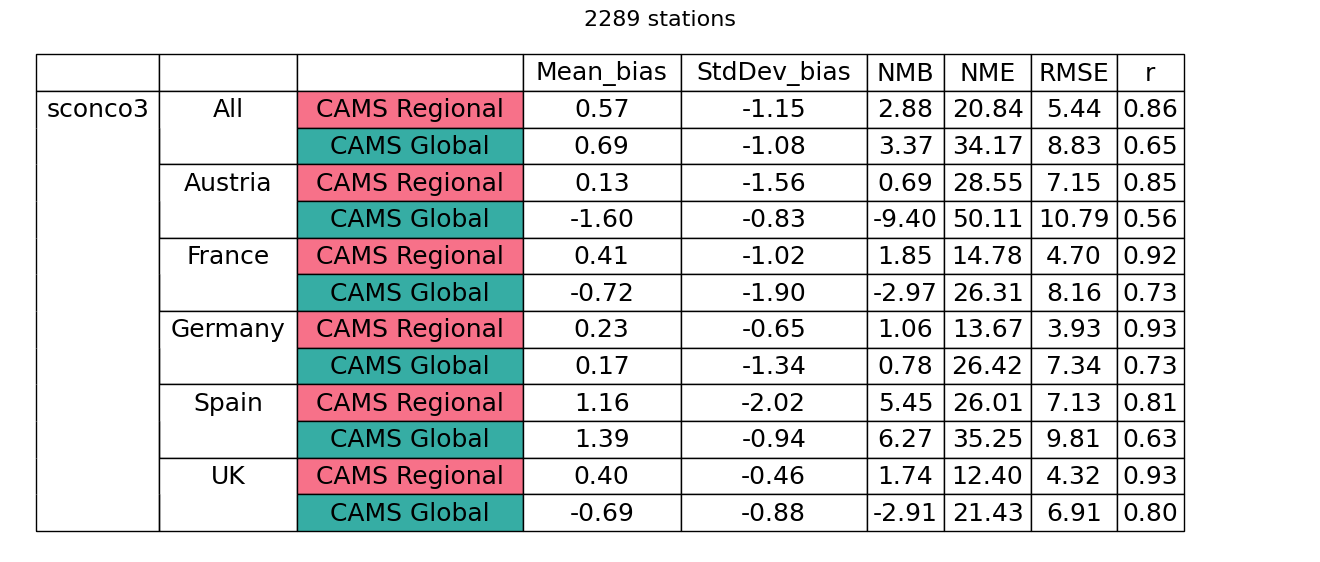

In [17]:
# make a statsummary plot
provi.plot('statsummary', multispecies=True, bias=True)